# Data Processing Algorithm for TRXRD

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import trxrd

%matplotlib widget

## Loading File Information

684 TIFF files found in C:\Users\lheald\Box\Sargent_Beamtime_Data\1p53ev_re_unaged\550nm.


c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:228: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(test + 1), cmap="jet")


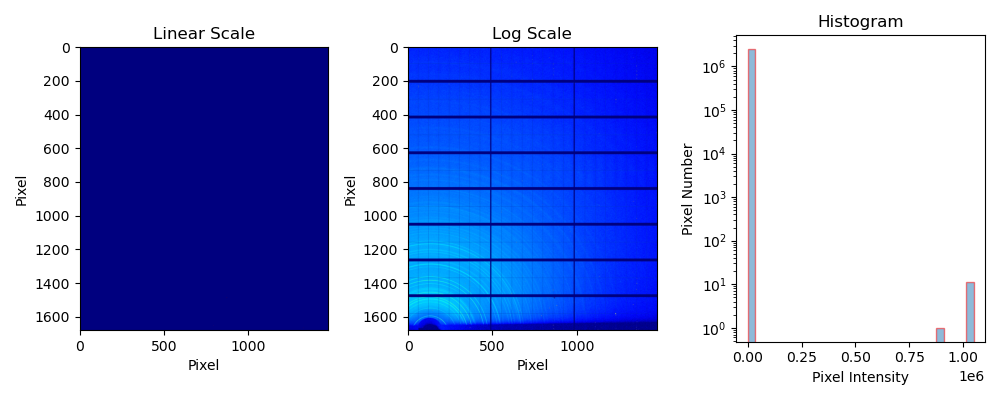

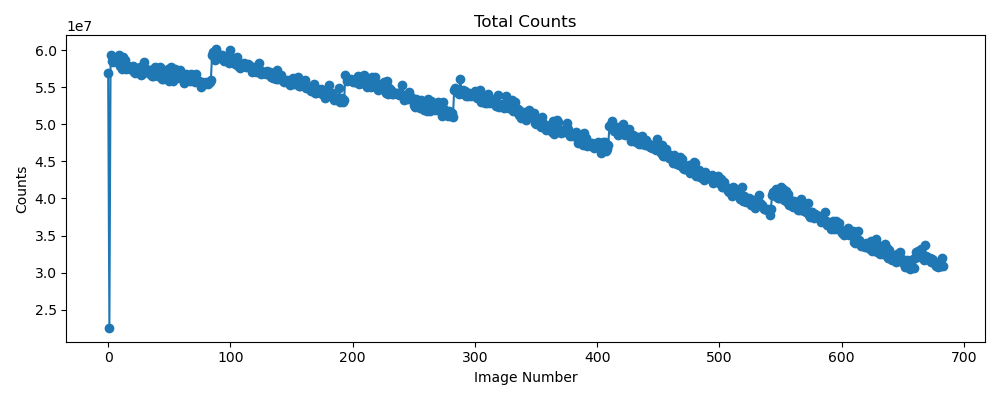

In [2]:
folder = Path(r"C:/Users/lheald/Box/Sargent_Beamtime_Data/1p53ev_re_unaged/550nm/")

data_dict = trxrd.get_image_details(folder, plot=True)

## Remove Images Based on Counts

1 images removed from 684 initial images


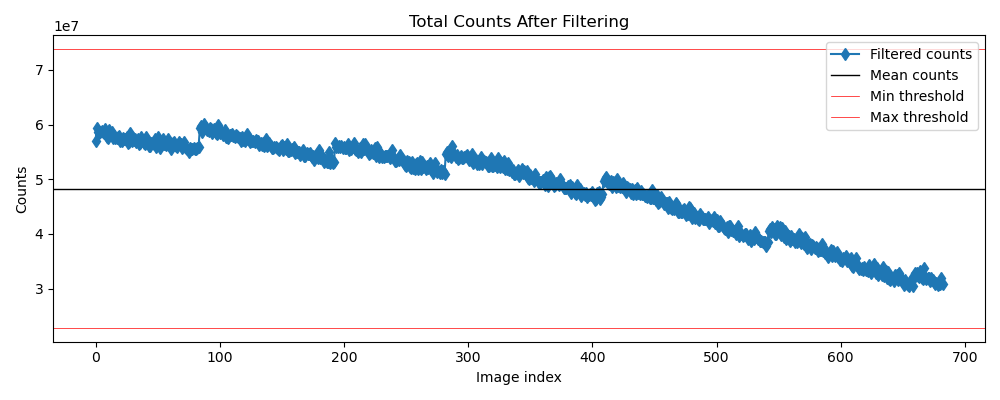

In [3]:
clean_dict = trxrd.remove_counts(data_dict, plot=True)
images_use = clean_dict["images"]

## Apply Mask to Data

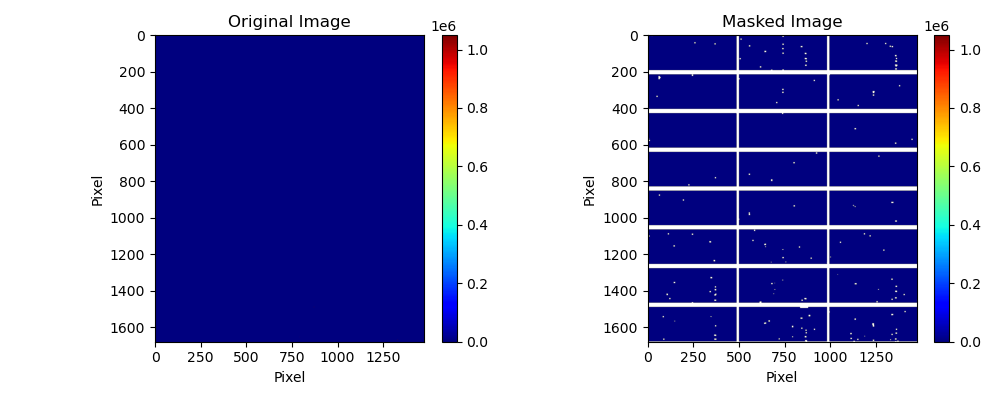

In [4]:
mask_file = r"C:\Users\lheald\Box\TRXRDPython\testdata\mask_2021_dec.tif"

masked_data = trxrd.apply_nan_mask(
    images_use,
    mask_path=mask_file,
    plot=True,
)

masked_dict = {
    "images": masked_data,
    "fluence": clean_dict["fluence"],
    "delay": clean_dict["delay"],
    "image_number": clean_dict["image_number"],
    "counts": clean_dict["counts"],
}

del data_dict
images_use = masked_dict["images"]

## Create Background Data

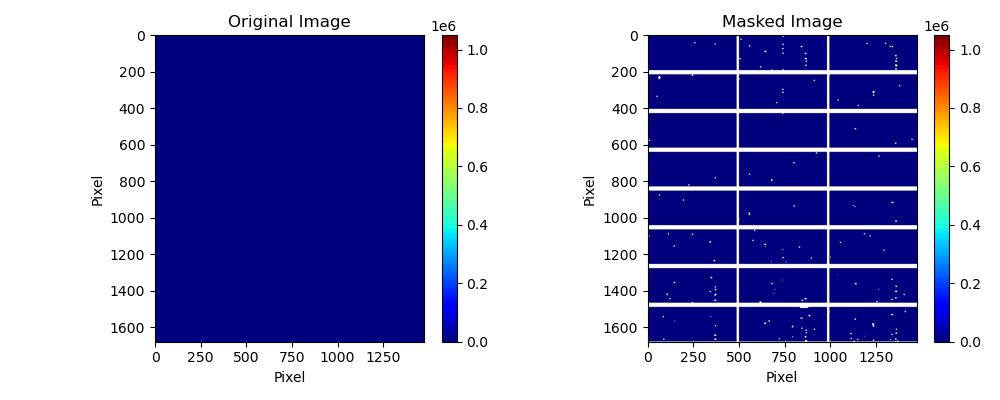

Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.


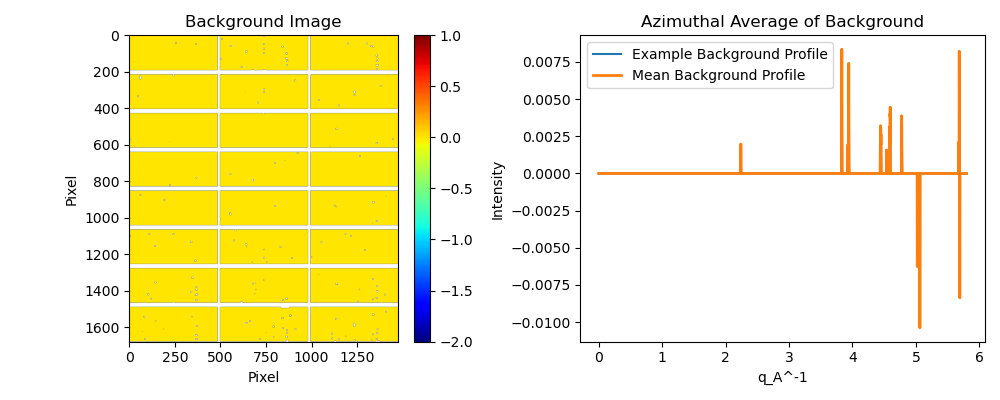

In [10]:
bg_path = Path(r"C:\Users\lheald\Box\Sargent_Beamtime_Data\FTObackground\Monday13_1.5-deg_theta2.36samz00002_11980.tif")

bg_dict = trxrd.load_background(bg_path)



bg_masked = trxrd.apply_nan_mask(bg_dict["background_stack"], mask_path=mask_file, plot=True)
bg_dict["background_stack"] = bg_masked
bg_az_dict = trxrd.compute_background_azimuthal_average(bg_dict, centers=(1710, 135), 
                                                        search_radius=20, r_max=None, downsample=2, radial_range=(0, 5.8), plot=True)

## Find Image Centers

### Faster Parallel Version

Finding centers for 683 images...
  Completed 100/683 (14.6%)
  Completed 200/683 (29.3%)
  Completed 300/683 (43.9%)
  Completed 400/683 (58.6%)
  Completed 500/683 (73.2%)
  Completed 600/683 (87.8%)
  Completed 683/683 (100.0%)
Done finding centers.


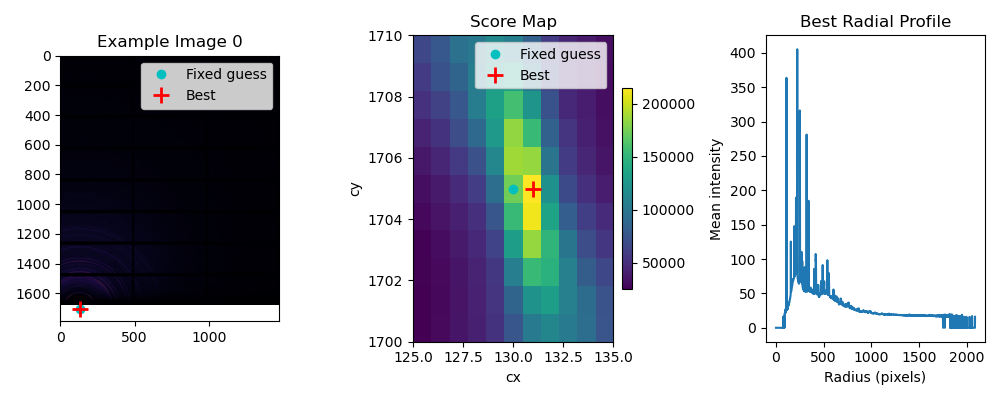

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:1304: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 1, figsize=figsize_trend, sharex=True)


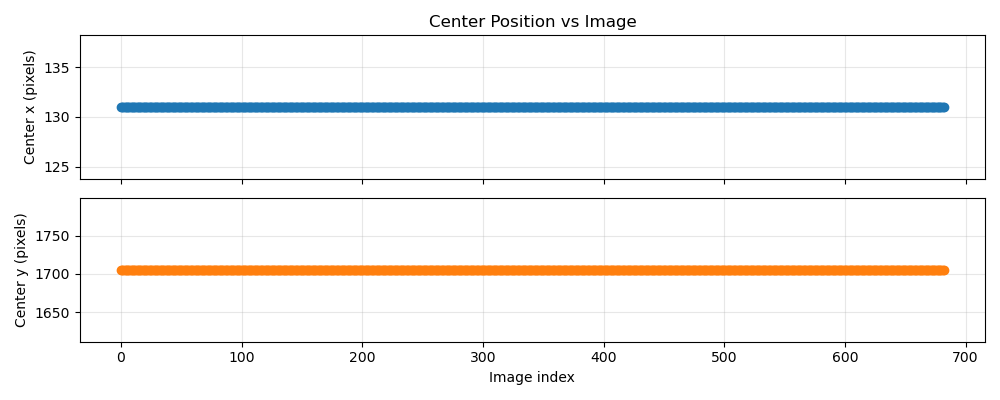

In [12]:
center_dict = trxrd.find_centers_in_stack_radial_parallel(
    images_use,
    center_guess=(1705, 130),
    search_radius=5,
    downsample=1,
    r_max=None,
    intensity_threshold=None, 
    top_percentile=60.0,
    plot_example=True,
    plot_center_vs_image=True)

center_x = np.array(center_dict["center_x"])
center_y = np.array(center_dict["center_y"])
centers = np.column_stack((center_x, center_y))

## Get Azimuthal Average using pyFAI

Integrating 683 images...
  Completed 100/683 (14.6%)
  Completed 200/683 (29.3%)
  Completed 300/683 (43.9%)
  Completed 400/683 (58.6%)
  Completed 500/683 (73.2%)
  Completed 600/683 (87.8%)
  Completed 683/683 (100.0%)
Done integrating.
q shape: (5000,)
profiles shape: (683, 5000)
delay shape: (683,)


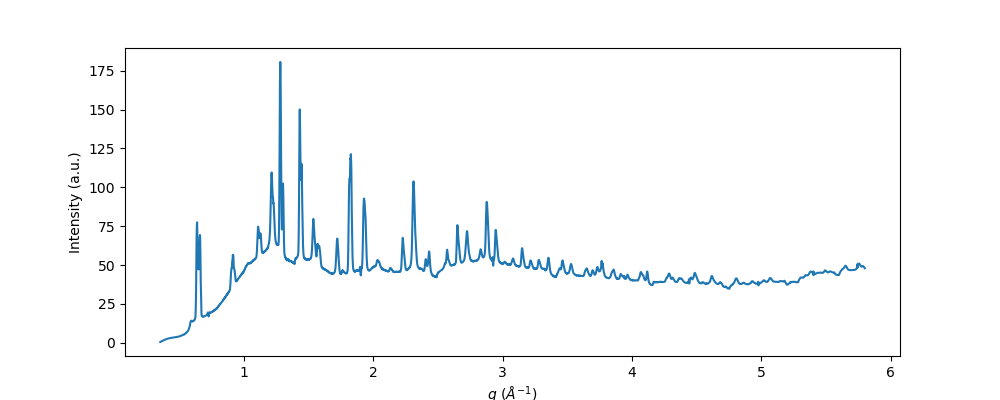

In [13]:
az_result = trxrd.azimuthal_average_pyfai(
    images=images_use,
    centers=centers,
    use_average_center=False,
    npt=5000,
    unit="q_A^-1",
    radial_range=(0, 5.8), 
    nan_radial_range=(0.35, None)
)

q = az_result["radial"]
profiles = az_result["profiles"]

print("q shape:", q.shape)
print("profiles shape:", profiles.shape)
print("delay shape:", masked_dict["delay"].shape)

plt.figure(figsize=(10, 4))
plt.plot(q, np.mean(profiles, axis=0))
plt.xlabel(r"$q$ ($\AA^{-1}$)")
plt.ylabel("Intensity (a.u.)") 
plt.show()

## Normalize Azimuthal Average to Specified Range

Normalization factor statistics:
  mode: mean
  norm_range: (0.75, 0.88)
  min:   12.9311
  max:   33.2936
  mean:  25.4342
  std:   6.04825
  # < 0: 0
  # > 0: 683
  # = 0: 0


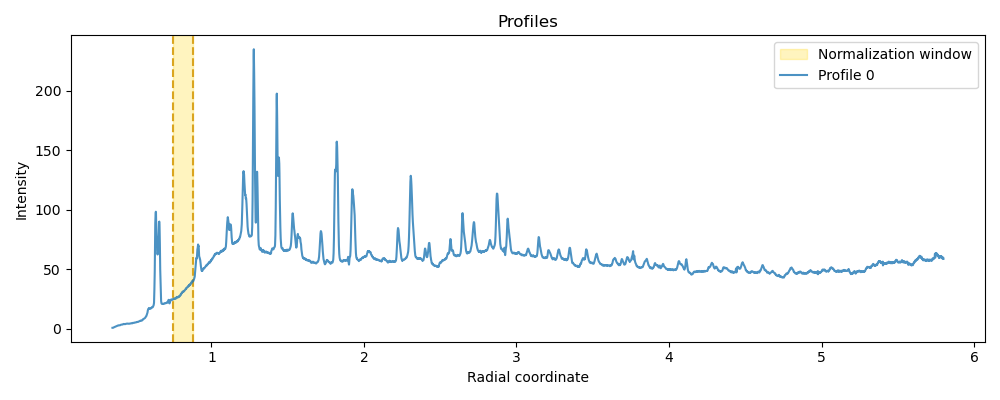

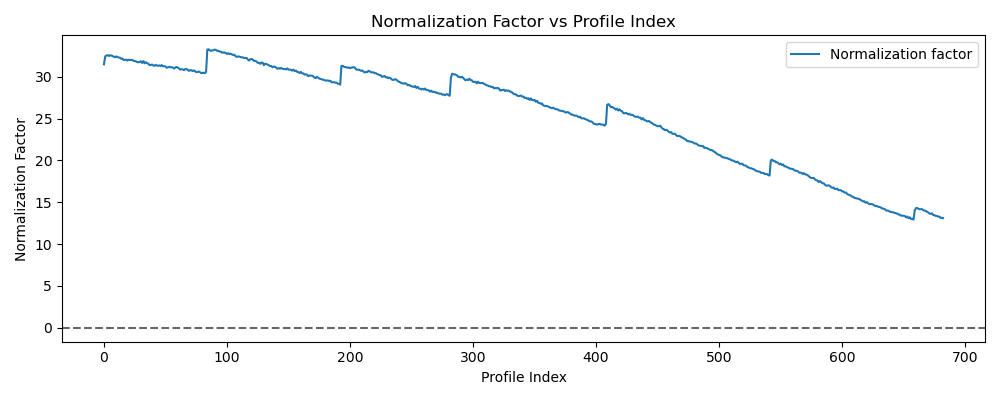

In [14]:
norm_result = trxrd.normalize_profiles_to_range(
    radial=q,
    profiles=profiles,
    norm_range=(0.75, 0.88),
    mode="mean",
    plot=True,
    plot_factors=True,
    print_factor_stats=True,
)

norm_profiles = norm_result["normalized_profiles"]

## Make Reference Set and Plot

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:2547: RuntimeWarning: Mean of empty slice
  reference_profile = np.nanmean(ref_group, axis=0)


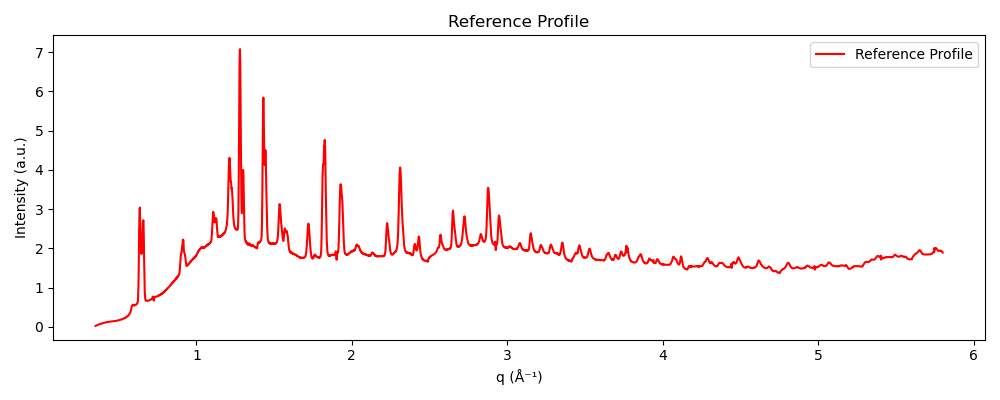

In [15]:
reference_result = trxrd.make_reference_profile(
    profiles=norm_profiles,
    delays=masked_dict["delay"],
)

reference_profile = reference_result["reference_profile"]

plt.figure(figsize=(10, 4))
plt.plot(q, reference_profile, label="Reference Profile", color="red")
plt.xlabel("q (Å⁻¹)")
plt.ylabel("Intensity (a.u.)")
plt.title("Reference Profile")
plt.legend()
plt.tight_layout()
plt.show()


## Compute Per-Image dI(Q)

In [16]:
delta_result = trxrd.compute_delta_profiles(
    profiles=norm_profiles,
    reference_profile=reference_profile,
    mode="subtract",   # use "relative" for dI/I
)

delta_iq = delta_result["delta_profiles"]

print("delta_iq shape:", delta_iq.shape)


delta_iq shape: (683, 5000)


## Average Normalized Data by Delay for Visualization

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd_lfh\trxrd.py:2471: RuntimeWarning: Mean of empty slice
  mean_profiles[i] = np.nanmean(group, axis=0)


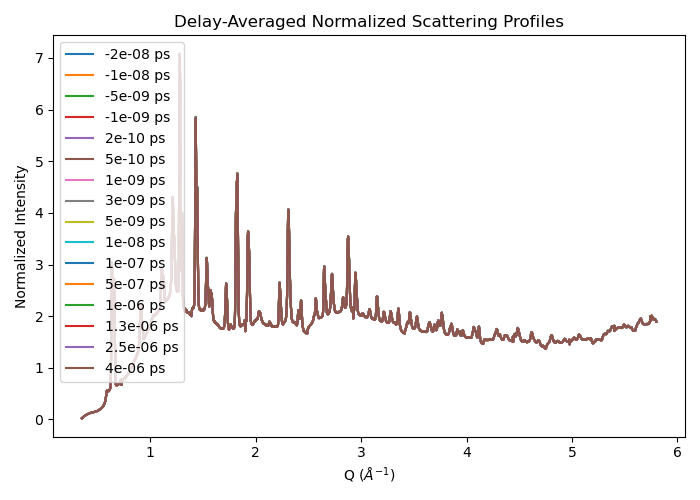

In [17]:
norm_delay_result = trxrd.average_profiles_by_delay(
    profiles=norm_profiles,
    delays=masked_dict["delay"],
)

unique_delays = norm_delay_result["unique_delays"]
mean_profiles = norm_delay_result["mean_profiles"]
std_profiles = norm_delay_result["std_profiles"]

plt.figure(figsize=(7, 5))
for j in range(len(unique_delays)):
    plt.plot(q, mean_profiles[j], label=f"{unique_delays[j]:.3g} ps")

plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Normalized Intensity")
plt.title("Delay-Averaged Normalized Scattering Profiles")
plt.legend()
plt.tight_layout()
plt.show()

## Average Delta Profiles by Delay for Visualization

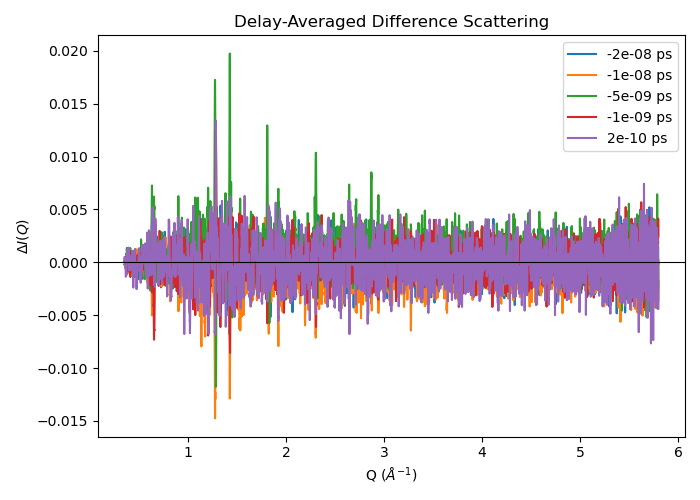

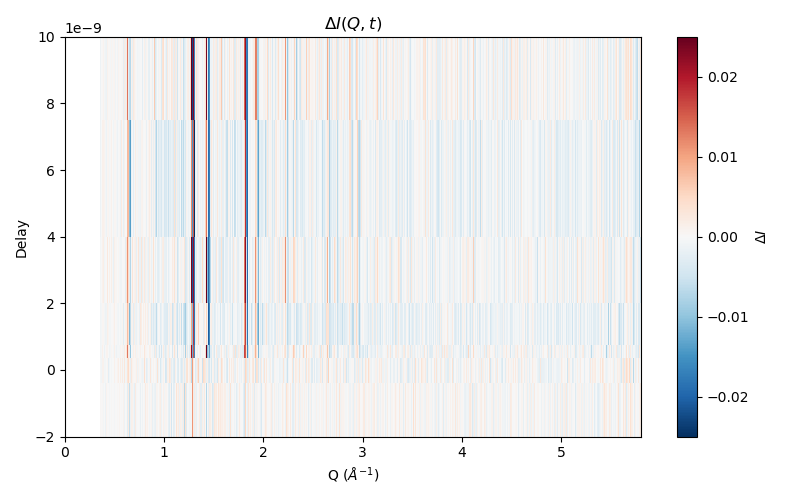

In [18]:
delta_delay_result = trxrd.average_profiles_by_delay(
    profiles=delta_iq,
    delays=masked_dict["delay"],
)

delta_unique_delays = delta_delay_result["unique_delays"]
delta_mean_profiles = delta_delay_result["mean_profiles"]
delta_std_profiles = delta_delay_result["std_profiles"]

plt.figure(figsize=(7, 5))
for j in range(min(5, len(delta_unique_delays))):
    plt.plot(q, delta_mean_profiles[j], label=f"{delta_unique_delays[j]:.3g} ps")

plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel(r"$\Delta I(Q)$")
plt.title("Delay-Averaged Difference Scattering")
plt.axhline(0, color="k", lw=0.8)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.pcolormesh(q, delta_unique_delays, delta_mean_profiles, shading="auto", cmap="RdBu_r")
plt.xlabel(r"Q ($\AA^{-1}$)")
plt.ylabel("Delay")
plt.title(r"$\Delta I(Q, t)$")
plt.colorbar(label=r"$\Delta I$")
plt.clim(-0.025, 0.025)
plt.ylim(-2e-9, 10e-9)
plt.tight_layout()
plt.show()


## Get Lineouts with Error Bars

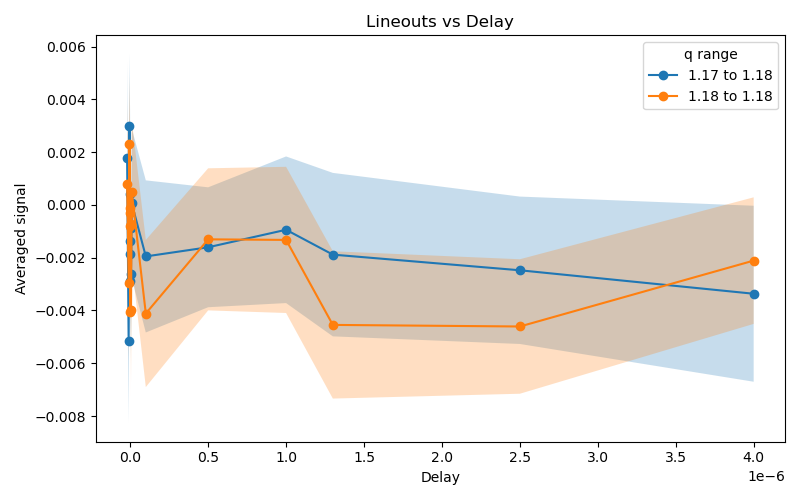

lineout delays: [-2.0e-08 -1.0e-08 -5.0e-09 -1.0e-09  2.0e-10  5.0e-10  1.0e-09  3.0e-09
  5.0e-09  1.0e-08  1.0e-07  5.0e-07  1.0e-06  1.3e-06  2.5e-06  4.0e-06]
mean_lineouts shape: (2, 16)
sem_lineouts shape: (2, 16)
counts per delay: [42 43 43 43 43 42 43 42 43 43 42 43 43 43 42 43]


In [19]:
lineout_result = trxrd.lineouts_by_delay_from_per_image_profiles(
    radial=q,
    delta_profiles=delta_iq,
    delays=masked_dict["delay"],
    q_ranges=[(1.166, 1.175), (1.176, 1.184)],
    average_mode="mean",
    error_type="sem",   # or "std"
    plot=True,
)

# Optional access to returned arrays
lineout_delays = lineout_result["unique_delays"]
mean_lineouts = lineout_result["mean_lineouts"]
std_lineouts = lineout_result["std_lineouts"]
sem_lineouts = lineout_result["sem_lineouts"]
counts_per_delay = lineout_result["counts_per_delay"]

print("lineout delays:", lineout_delays)
print("mean_lineouts shape:", mean_lineouts.shape)
print("sem_lineouts shape:", sem_lineouts.shape)
print("counts per delay:", counts_per_delay)